# Интеллектуальный анализ данных – весна 2025
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('./tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
25038,34454,79406,"The Goldfields, Victoria, Australia",06-04-2020,Government boosts seniors meal delivery amid C...,Extremely Positive
28525,38801,83753,home,08-04-2020,How you finding online shopping everyone? - Ge...,Negative
24336,33561,78513,"Walsall, England",05-04-2020,Oh my god IÃÂve just been for supplies from ...,Positive
28678,38990,83942,Ferrum Stadium (She/Her),08-04-2020,the end half of 2020 is shaping up to be a gre...,Negative


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [3]:
df['Sentiment'] = df['Sentiment'].map({
    'Positive': 1,
    'Extremely Positive': 1,
    'Negative': 0,
    'Extremely Negative': 0
})
df['Sentiment'].value_counts()

Sentiment
1    18046
0    15398
Name: count, dtype: int64

Сбалансированы ли классы?

In [4]:
df['Sentiment'].value_counts(normalize=True)

Sentiment
1    0.539589
0    0.460411
Name: proportion, dtype: float64

**Ответ:** Классы почти сбалансированы, около 50% одного и другого классов

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [5]:
# -- YOUR CODE HERE --
df.isnull().sum()

UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [6]:
df['Location'] = df['Location'].fillna('Unknown')
df.isnull().sum()

UserName         0
ScreenName       0
Location         0
TweetAt          0
OriginalTweet    0
Sentiment        0
dtype: int64

Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [7]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=0)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [8]:
# -- YOUR CODE HERE --
import nltk
from nltk import word_tokenize
nltk.download("punkt_tab", quiet=True)

True

Какой размер словаря получился?

In [9]:
# -- YOUR CODE HERE --
from collections import Counter

tokens = [ word_tokenize(text.lower()) for text in train['OriginalTweet']]
print(tokens)

[['why', 'we', 'still', 'want', 'to', 'buy', 'so', 'much', 'stuff', 'during', 'quarantine', 'https', ':', '//t.co/1m881cwfuv', '#', 'shopping', '#', 'covid_19', '#', 'online'], ['with', 'driving', 'even', 'more', 'usage', 'a', 'strong', 'strategy', 'is', 'critical', 'now', 'more', 'then', 'ever', 'luckily', 'and', 'april', '16', 'webinar', 'will', 'dive', 'into', 'growing', 'app', 'awareness', 'and', 'targeting', 'high', 'lifetime', 'value', 'users'], ['@', 'canon_india', 'i', 'am', 'very', 'happy', '..', 'great', 'job', 'by', '@', 'canon_india', '#', 'canonforcommunity', 'https', ':', '//t.co/z0intks34x'], ['the', 'u.s', 'national', 'debt', 'will', 'likely', 'exceed', '$', '30', 'trillion', 'after', 'the', 'unprecedented', 'borrowing', 'by', 'the', 'trump', 'administration', 'and', 'mnuchinã\x82â\x92s', 'treasury', 'during', 'the', '#', 'coronavirus', 'crisis', '.', 'the', 'federal', 'reserve', 'could', 'be', 'doing', 'much', 'more', 'to', 'cushion', 'the', 'blow', '.', 'u.s', 'is', '

Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [10]:
# -- YOUR CODE HERE --
count = Counter([word.lower() for text in tokens for word in text])
count.most_common(10)

[('#', 42753),
 ('the', 26928),
 ('to', 23466),
 ('.', 22737),
 (',', 17556),
 (':', 16478),
 ('and', 14792),
 ('of', 13043),
 ('https', 12921),
 ('a', 11833)]

**Ответ:** # - самый популярный потому, что теги в твиттере очень распространены, the и to слова связи, которые очень часто встречаются в англиском 

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [11]:
import nltk
from nltk.corpus import stopwords

for stopword in stopwords.words('english'):
    if stopword in count:
        del count[stopword]
count.most_common(10)

[('#', 42753),
 ('.', 22737),
 (',', 17556),
 (':', 16478),
 ('https', 12921),
 ('?', 11033),
 ('coronavirus', 9965),
 ('@', 9959),
 ('!', 4700),
 ('prices', 4618)]

**Ответ:** теперь топ 1 стал https, посколько очевидно с него начинаются ссылки, короновирус объяснять не надо думаю, и цены думаю потому что многие делятся товарами и их ценами в соц сети

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [12]:
# -- YOUR CODE HERE --
count.most_common()[-20:]

[('//t.co/lw1r0rm7xs', 1),
 ('//t.co/5cbliqzx7l', 1),
 ('now.when', 1),
 ('milion', 1),
 ('skellig', 1),
 ('skelligsix18', 1),
 ('skelligcoast2kms', 1),
 ('southkerry', 1),
 ('//t.co/zjcl195vqs', 1),
 ('srinivasiyc', 1),
 ('//t.co/iaek4fwsgz', 1),
 ('premiership', 1),
 ('non-playing', 1),
 ('subsidise', 1),
 ('playersã\x82â\x92', 1),
 ('renewing', 1),
 ('flew', 1),
 ('torontopearson', 1),
 ('680news', 1),
 ('//t.co/7j2y3rsld9', 1)]

**Ответ:** Данные токеты похожи на некоторые ссылки и просто какие-то рандомные слова, учитывая, то что они встречаются по разу думаю их можно просто удалить из словаря.


Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [13]:
from nltk.tokenize import TweetTokenizer
tw = TweetTokenizer(preserve_case=False)

count = Counter([word for text in train['OriginalTweet'] for word in tw.tokenize(text)])
count.most_common(10)
# -- YOUR CODE HERE --

[('the', 26993),
 ('.', 24118),
 ('to', 23478),
 (',', 17571),
 ('and', 14825),
 ('of', 13044),
 ('a', 11891),
 ('in', 11348),
 ('?', 9524),
 ('#coronavirus', 8808)]

**Ответ:** Все еще видно, что присутсвует много знаков припенания и различных союзов и артиклей, те служебной части речи, которая сама по себе информации не несет. Но теперь хештеги выделяются вместе с `#`, а не без него 

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [14]:
from string import punctuation

# -- YOUR CODE HERE --
for word in stopwords.words('english') + list(punctuation):
    if word in count:
        del count[word]
count.most_common(10)

[('#coronavirus', 8808),
 ('â', 7415),
 ('\x82', 7311),
 ('19', 7167),
 ('covid', 6253),
 ('prices', 4601),
 ('\x92', 4372),
 ('food', 4367),
 ('store', 3877),
 ('supermarket', 3805)]

**Ответ:** Теперь топ 1 стал хеш тег с короной, далее спец. символы какие-то.


Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [15]:
# -- YOUR CODE HERE --
for w in range(128,256):
    if chr(w) in count:
        del count[chr(w)]
count.most_common(10)

[('#coronavirus', 8808),
 ('19', 7167),
 ('covid', 6253),
 ('prices', 4601),
 ('food', 4367),
 ('store', 3877),
 ('supermarket', 3805),
 ('grocery', 3523),
 ('people', 3463),
 ('#covid19', 2589)]

In [16]:
count.most_common()[-20:]

[('https://t.co/LW1r0Rm7XS', 1),
 ('https://t.co/5cBLIqZX7L', 1),
 ('now.when', 1),
 ('milion', 1),
 ('skellig', 1),
 ('@skelligsix18', 1),
 ('#skelligcoast2kms', 1),
 ('#southkerry', 1),
 ('https://t.co/zJcL195VQS', 1),
 ('@srinivasiyc', 1),
 ('https://t.co/IAEK4fWsgz', 1),
 ('premiership', 1),
 ('non-playing', 1),
 ('subsidise', 1),
 ('playersã', 1),
 ('renewing', 1),
 ('flew', 1),
 ('@torontopearson', 1),
 ('@680news', 1),
 ('https://t.co/7j2Y3rSld9', 1)]

**Ответ:** Наш словарь стал более осмысленным в топ 10, и в том 20 наименее используемых слов, стали попадаться адекватные слова, ссылки и хештеги

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [17]:
# -- YOUR CODE HERE --
most_common_tegs = Counter({word: value for word, value in count.items() if word.startswith('#')})
most_common_tegs.most_common(10)

[('#coronavirus', 8808),
 ('#covid19', 2589),
 ('#covid_19', 1734),
 ('#covid2019', 946),
 ('#toiletpaper', 744),
 ('#covid', 641),
 ('#socialdistancing', 465),
 ('#coronacrisis', 448),
 ('#pandemic', 257),
 ('#coronaviruspandemic', 249)]

**Ответ:** Очевидно, что все теги будут связаны с ковидом, теги про: ковид, таулетную бумагу, домашнее обучение и кризис. Прекрасное было время.

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [18]:
# -- YOUR CODE HERE --
most_common_links = Counter({word: value for word, value in count.items() if word.startswith('https://t.co')})
most_common_links.most_common(10)

[('https://t.co/oXA7SWtoNd', 5),
 ('https://t.co/gP3EusapL8', 4),
 ('https://t.co/DefTruI1PfÃ\x82Â', 3),
 ('https://t.co/WrLHYzIzAA', 3),
 ('https://t.co/kuwIpF1KQW', 3),
 ('https://t.co/zjNRx6dKKN', 3),
 ('https://t.co/3GBBDpdjat', 3),
 ('https://t.co/e2ZNXajPre', 3),
 ('https://t.co/CATKegAyOY', 3),
 ('https://t.co/G63RP042HO', 3)]

**Ответ:** Вообще не сравнима, то что самую популярную ссылку использовали 5 раз говорит о том, что их так же можно удалить 

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [19]:
def custom_tokenizer(text):

  # -- YOUR CODE HERE --
  text = text.lower()
  tw = TweetTokenizer(preserve_case=False)
  tokens = tw.tokenize(text)
  def check(word):
    if len(word) == 1 and ord(word) > 127:
      return False
    if word in stopwords.words("english"):
      return False
    if word in punctuation:
      return False
    if word.startswith("https://t.co"):
      return False
    return True

  return list(filter(check, tokens))


In [20]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer)
cv.fit(train['OriginalTweet'])
print(len(cv.vocabulary_))

45290


In [22]:
len(count)/ len(cv.vocabulary_) 

1.2826010156767498

**Ответ:** наш кастомный токенайзер делает меньше токенов, но делает их более валидными

Посмотрим на какой-нибудь конкретный твитт:

In [23]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 0)

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [24]:
# -- YOUR CODE HERE --
tweet =  cv.transform([train.iloc[ind]['OriginalTweet']])

features_names = cv.get_feature_names_out()
non_zeros_indices = tweet.nonzero()[1]
values = tweet.data

word_freq = {features_names[i]: val for i, val in zip(non_zeros_indices, values)}

max_token = max(word_freq, key=word_freq.get)
min_token = min(word_freq, key=word_freq.get)

print(f"Твит: {train.iloc[ind]['OriginalTweet']}")
print(f"Самый важный (частый) токен: {max_token} ({word_freq[max_token]})")
print(f"Самый неважный токен: {min_token} ({word_freq[min_token]})")

Твит: Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs
Самый важный (частый) токен: #coronavirusoutbreak (1)
Самый неважный токен: #coronavirusoutbreak (1)


In [25]:
word_freq

{'#coronavirusoutbreak': 1,
 '#covid2019': 1,
 '@skynews': 1,
 'brainless': 1,
 'ffs': 1,
 'food': 1,
 'france': 1,
 'lets': 1,
 'nice': 1,
 'one': 1,
 'panic': 1,
 'ppl': 1,
 'queueing': 1,
 'show': 1}

**Ответ:** Получили, что тег сам по себе и самый важный и неважный одновременно, что противоречит само себе

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [26]:
# -- YOUR CODE HERE --
from sklearn.feature_extraction.text import TfidfVectorizer

tf = TfidfVectorizer(tokenizer=custom_tokenizer)
tf.fit(train['OriginalTweet'])

tweet_tfidf = tf.transform([train.iloc[ind]['OriginalTweet']])
feature_names_tf = tf.get_feature_names_out()

word_tfidf = {feature_names_tf[i]: val for i, val in zip(tweet_tfidf.indices, tweet_tfidf.data)}

print(f"Самый важный (max tf-idf): {max(word_tfidf, key=word_tfidf.get)}")
print(f"Самый неважный (min tf-idf): {min(word_tfidf, key=word_tfidf.get)}")

Самый важный (max tf-idf): brainless
Самый неважный (min tf-idf): food


**Ответ:** Здесь уже слова различают, и это намного лучше, чем было до, поскольку понятно, что токен `brainless` негативно окрашивает твит. А токен `food` сам по себе информации о твите особо не несет с эмоциональной точки зрения

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [27]:
train[train['OriginalTweet'].apply(lambda x: 'good' in x) & (train['Sentiment'] == 1)]

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
21541,30079,75031,Unknown,02-04-2020,"To all my marketers friends, this is a very go...",1
20314,28576,73528,"New Delhi, India",27-03-2020,India on lockdown...I'm more worried by death ...,1
192,4035,48987,"San Diego, CA",16-03-2020,"What's a good way to support grocery store, me...",1
5140,10048,55000,New Zealand,19-03-2020,Countdown supermarket limiting some goods: You...,1
19139,27090,72042,Unknown,25-03-2020,@MorganRadford good segment! BTW where did yo...,1
...,...,...,...,...,...,...
19361,27366,72318,Unknown,26-03-2020,@jichiemin LetÃÂs hope it not #coronavirus ?...,1
6250,11382,56334,"Mumbai, India",19-03-2020,Respected Sir @narendramodi \r\r\n\r\r\nWe und...,1
15997,23260,68212,sales@esmmagazine.com,24-03-2020,#Consumer goods giant @Unilever Plc said on Tu...,1
18819,26706,71658,"Chicago, IL",25-03-2020,Online grocery shopping? Here are some good ti...,1


In [28]:
# -- YOUR CODE HERE --
tweet = train.loc[21541]
tweet['OriginalTweet']

'To all my marketers friends, this is a very good article by @McKinsey regarding customer sentiment during the #coronavirus crisis. Are you ready to change your whole marketing strategy? #MarketingStrategy \r\r\nhttps://t.co/plN1H6qYLw'

In [29]:
features = tf.get_feature_names_out()
tweetX = tf.transform([tweet["OriginalTweet"]])
best = np.argmax(tweetX)
print("Best", features[best])
print("vocabulary[best] =", tf.vocabulary_[features[best]])

Best #marketingstrategy
vocabulary[best] = 5193


**Ответ:** 

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [30]:
# -- YOUR CODE HERE --
X_train, y_train = train.drop(columns=["Sentiment"]), train["Sentiment"]
X_test, y_test = test.drop(columns=["Sentiment"]), test["Sentiment"]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((23410, 5), (23410,), (10034, 5), (10034,))

In [31]:
cv_vec_train = cv.fit_transform(X_train["OriginalTweet"])
cv_vec_test = cv.transform(X_test["OriginalTweet"])

tfidf_vec_train = tf.fit_transform(X_train["OriginalTweet"])
tfidf_vec_test = tf.transform(X_test["OriginalTweet"])

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -- YOUR CODE HERE --
lr1 = LogisticRegression()
lr1.fit(cv_vec_train, y_train)
print("Train accuracy:", accuracy_score(y_train, lr1.predict(cv_vec_train)))
print("Accuracy (CountVectorizer):", accuracy_score(y_test, lr1.predict(cv_vec_test))) 

Train accuracy: 0.9846646732165741
Accuracy (CountVectorizer): 0.8670520231213873


In [33]:
lr2 = LogisticRegression() 
lr2.fit(tfidf_vec_train, y_train)
print("Train accuracy:", accuracy_score(y_train, lr2.predict(tfidf_vec_train)))
print("Accuracy (TfidfVectorizer):", accuracy_score(y_test, lr2.predict(tfidf_vec_test)))

Train accuracy: 0.9224263135412217
Accuracy (TfidfVectorizer): 0.85280047837353


**Ответ:** Обе регресси показали хорошие результаты, но у модели обученной на нашем токенайзере, точность немного больше

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [34]:
from nltk.stem import SnowballStemmer

def custom_stem_tokenizer(text):
    text = text.lower()
    tw = TweetTokenizer(preserve_case=False)
    tokens = tw.tokenize(text)
    
    stemmer = SnowballStemmer("english")
    
    def check(word):
        if len(word) == 1 and ord(word) > 127:
            return False
        if word in stopwords.words("english"):
            return False
        if word in punctuation:
            return False
        if word.startswith("https://t.co"):
            return False
        return True

    return [stemmer.stem(token) for token in tokens if check(token)]

In [35]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [36]:
cv_stem = CountVectorizer(tokenizer=custom_stem_tokenizer)
cv_stem.fit(train['OriginalTweet'])

print(len(cv_stem.vocabulary_))

36634


In [37]:
print(len(cv.vocabulary_)/ len(cv_stem.vocabulary_))

1.2362832341540646


In [38]:
tf_stem = TfidfVectorizer(tokenizer=custom_tokenizer)
tf_stem.fit(train['OriginalTweet'])

print(len(tf_stem.vocabulary_))

45290


**Ответ** размер словаря уменьшился при использовании стемминга, причем примерно в 1.2 раза. Это связано с тем, что стемминг приводит слова к их основе, что позволяет уменьшить размер словаря.

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [39]:
# -- YOUR CODE HERE --
cv_stemming_vec_train = cv_stem.fit_transform(X_train["OriginalTweet"])
cv_stemming_vec_test = cv_stem.transform(X_test["OriginalTweet"])

tfidf_stemming_vec_train = tf_stem.fit_transform(X_train["OriginalTweet"])
tfidf_stemming_vec_test = tf_stem.transform(X_test["OriginalTweet"])

In [40]:
cv_stemming_logreg = LogisticRegression(max_iter=1000)
cv_stemming_logreg.fit(cv_stemming_vec_train, y_train)

print("Train accuracy:", accuracy_score(y_train, cv_stemming_logreg.predict(cv_stemming_vec_train)))
print("Test accuracy:", accuracy_score(y_test, cv_stemming_logreg.predict(cv_stemming_vec_test)))

Train accuracy: 0.9720205040580948
Test accuracy: 0.8674506677297189


In [41]:
tfidf_stemming_logreg = LogisticRegression(max_iter=1000)
tfidf_stemming_logreg.fit(tfidf_stemming_vec_train, y_train)

print("Train accuracy:", accuracy_score(y_train, tfidf_stemming_logreg.predict(tfidf_stemming_vec_train)))
print("Test accuracy:", accuracy_score(y_test, tfidf_stemming_logreg.predict(tfidf_stemming_vec_test)))

Train accuracy: 0.9224263135412217
Test accuracy: 0.85280047837353


In [42]:


data = [
    ["CountVectorizer", len(cv.vocabulary_), accuracy_score(y_test, lr1.predict(cv_vec_test))],
    ["CountVectorizer_stemming", len(cv_stem.vocabulary_), accuracy_score(y_test, cv_stemming_logreg.predict(cv_stemming_vec_test))],
    ["TfidfVectorizer",  len(tf.vocabulary_), accuracy_score(y_test, lr2.predict(tfidf_vec_test))],
    ["TfidfVectorizer_stemming", len(tf_stem.vocabulary_), accuracy_score(y_test, tfidf_stemming_logreg.predict(tfidf_stemming_vec_test))]
]

df_compare = pd.DataFrame(data, columns=["Vectorizer", "Vocab Size", "Test Accuracy"])
df_compare

,Vectorizer,Vocab Size,Test Accuracy
0,CountVectorizer,45290,0.867052
1,CountVectorizer_stemming,36634,0.867451
2,TfidfVectorizer,45290,0.852800
3,TfidfVectorizer_stemming,45290,0.852800


**Ответ:**  На нашем токенейзере стемминг немного повисл точность на тесте, ну а на tf-idf он остался аналогичным

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [43]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        max_df=7000# -- YOUR CODE HERE --
                        ).fit(X_train["OriginalTweet"])
print(len(cv_df.vocabulary_))

36633


Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [44]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df=10
                        ).fit(
                            X_train["OriginalTweet"]
                            )
print(len(cv_df.vocabulary_))

3918


In [45]:
from tqdm import tqdm
for test_value in tqdm(range(11, 25)):
    cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                            min_df=test_value
                            ).fit(
                                X_train["OriginalTweet"]
                                )
    if len(cv_df.vocabulary_) <= 3700:
        print("min_df =", test_value)
        print("len(cv_df.vocabulary_) =", len(cv_df.vocabulary_))
        break

  0%|          | 0/14 [00:31<?, ?it/s]

min_df = 11
len(cv_df.vocabulary_) = 3687


**Ответ:** Ровно 3700 токенов не получилось и не получится, так как количество токенов монотонно убывает при увеличении min_df, а пограничное значение — 11 (при min_df = 10 токенов 3918, слишком много).

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

Train accuracy: 0.9414780008543358
Test accuracy: 0.8447279250548136


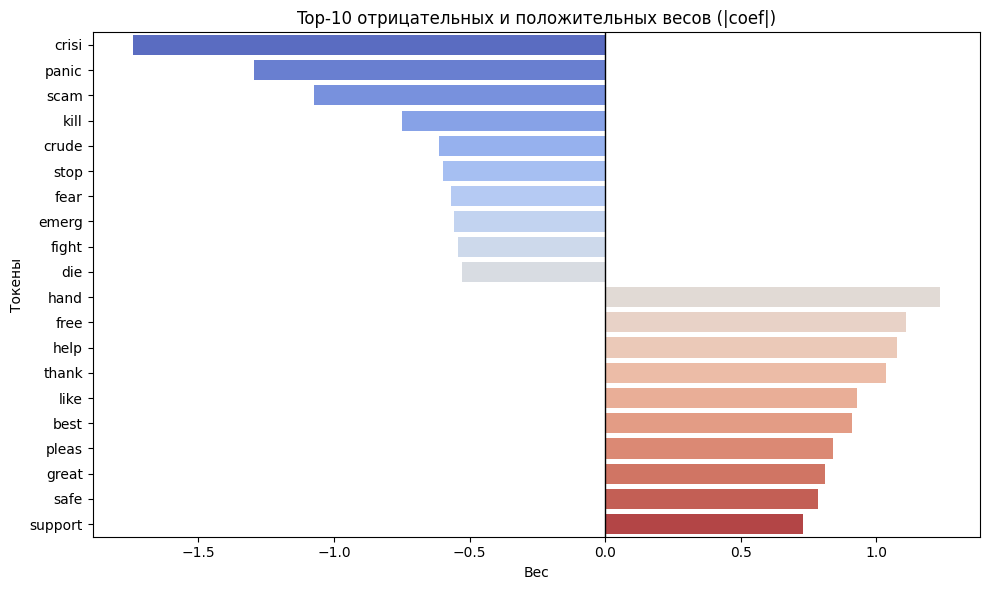

In [54]:
from sklearn.preprocessing import StandardScaler
# -- YOUR CODE HERE --
cv_37 = CountVectorizer(tokenizer=custom_stem_tokenizer, min_df=11)
X_train_cv = cv_37.fit_transform(X_train["OriginalTweet"])
X_test_cv = cv_37.transform(X_test["OriginalTweet"])

# масштабирование sparse (без центрирования)
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_cv)
X_test_scaled = scaler.transform(X_test_cv)

# логрег
lr_scaled = LogisticRegression(max_iter=2000)
lr_scaled.fit(X_train_scaled, y_train)

print("Train accuracy:", accuracy_score(y_train, lr_scaled.predict(X_train_scaled)))
print("Test accuracy:", accuracy_score(y_test, lr_scaled.predict(X_test_scaled)))

# веса и barplot
feature_names = np.array(cv_37.get_feature_names_out())
coefs = lr_scaled.coef_.ravel()

top_pos_idx = np.argsort(coefs)[-10:][::-1]
top_neg_idx = np.argsort(coefs)[:10]

top_features = np.concatenate([feature_names[top_neg_idx], feature_names[top_pos_idx]])
top_weights = np.concatenate([coefs[top_neg_idx], coefs[top_pos_idx]])

plt.figure(figsize=(10, 6))
sns.barplot(x=top_weights, y=top_features, palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top-10 отрицательных и положительных весов (|coef|)")
plt.xlabel("Вес")
plt.ylabel("Токены")
plt.tight_layout()
plt.show()

**Ответ:** Топ отрицательных токенов отражает негативную лексику и тревожные слова, положительные — поддерживающую лексику. Это интерпретируемые признаки, согласуются с задачей тональности.

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [57]:
# -- YOUR CODE HERE --
df['UserName'].nunique()

33444

In [58]:
df['ScreenName'].nunique()

33444

In [59]:
df.shape

(33444, 6)

**Ответ:** количество уникальных имен пользователей и отображаемых имен пользователей совпадает с количеством твитов, что говорит о том, что каждый твит был написан уникальным пользователем. Поэтому эти признаки играют роль идентификаторов и не несут никакой смысловой нагрузки.

In [60]:
X_train, X_test = X_train.drop(columns=["UserName", "ScreenName"]), X_test.drop(columns=["UserName", "ScreenName"])
X_train.shape, X_test.shape

((23410, 3), (10034, 3))

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [61]:
# -- YOUR CODE HERE --
X_train["TweetAt"] = pd.to_datetime(X_train["TweetAt"], format="%d-%m-%Y")
X_train["TweetAt"].head()

25621   2020-04-06
30135   2020-04-10
28899   2020-04-09
5989    2020-03-19
4367    2020-03-18
Name: TweetAt, dtype: datetime64[ns]

In [62]:
X_train["TweetAt"].nunique()

30

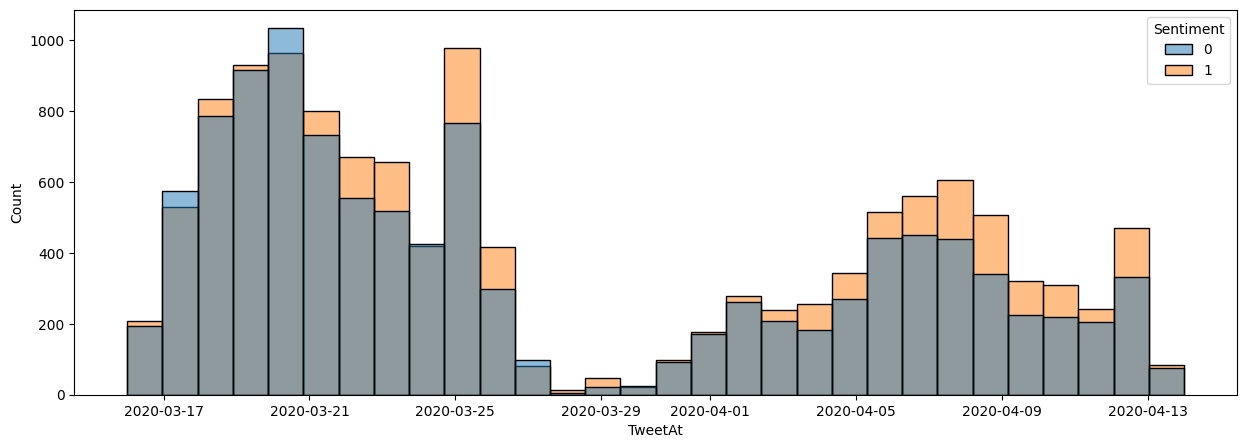

In [63]:

fig, ax = plt.subplots(figsize=(15, 5))
sns.histplot(data=pd.concat([X_train, y_train], axis=1), x="TweetAt", hue="Sentiment", bins=30, ax=ax);

**Ответ:** почти в каждый из дней положительные твиты преобладают над отрицательными. Из-за этого данный признак будет мало полезен для классификации твитов по эмоциональной окраске. Исключим его из X_train и X_test.



Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [65]:
# -- YOUR CODE HERE --
locations = X_train["Location"].value_counts()
locations

Location
Unknown                           4944
London                             301
United States                      295
London, England                    274
New York, NY                       223
                                  ... 
Work: Kent and Live: Sussex          1
Somewhere on TradingView             1
Honolulu, Hawai?i                    1
SFO                                  1
Waterville, Ireland Austin, TX       1
Name: count, Length: 7949, dtype: int64

In [66]:
X_train["Location"].nunique()

7949

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

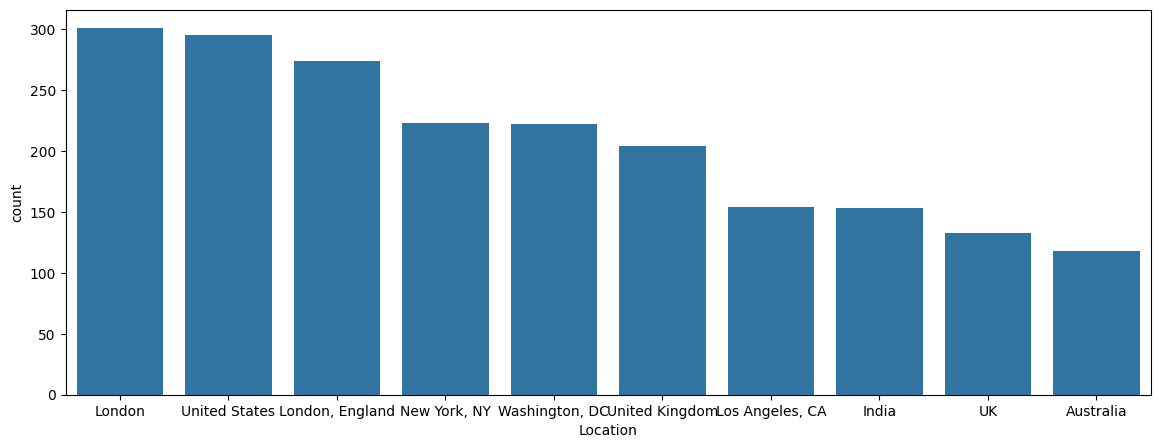

In [67]:
# -- YOUR CODE HERE --
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=locations.drop("Unknown").head(10), ax=ax);

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

In [68]:
# -- YOUR CODE HERE --
def wider_location(location: str) -> str:
    splitted = location.split(", ")
    return splitted[-1]

X_train["WiderLocation"], X_test["WiderLocation"] = X_train["Location"].apply(wider_location), X_test["Location"].apply(wider_location)
wider_locations = X_train["WiderLocation"].value_counts()
wider_locations

WiderLocation
Unknown                    4944
USA                         950
England                     860
CA                          597
India                       535
                           ... 
The DC & The OC               1
UK - Europe                   1
not Drumpf's Reich USSR       1
iowa                          1
NIGERIA                       1
Name: count, Length: 4921, dtype: int64

In [70]:
X_train["WiderLocation"].nunique()

4921

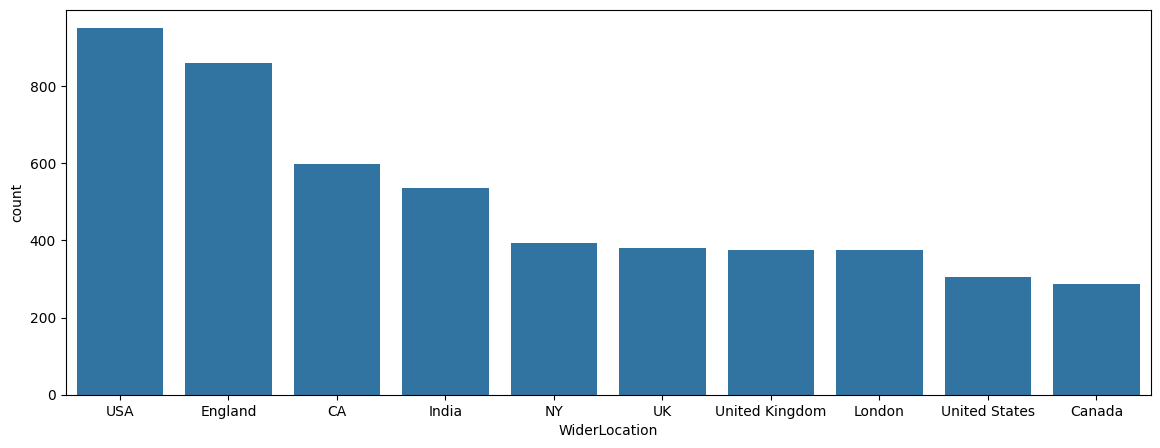

In [71]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=wider_locations.drop("Unknown").head(10), ax=ax);

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [73]:
# -- YOUR CODE HERE --
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
    categories=[wider_locations[wider_locations > 1].index.drop("Unknown").tolist()]
)
X_train_wider_locations = ohe.fit_transform(X_train[["WiderLocation"]])
X_test_wider_locations = ohe.transform(X_test[["WiderLocation"]])
X_train_wider_locations.shape, X_test_wider_locations.shape

((23410, 1009), (10034, 1009))

Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [75]:

from scipy.sparse import hstack, csr_matrix

X_train_loc = csr_matrix(X_train_wider_locations)
X_test_loc = csr_matrix(X_test_wider_locations)

X_train_combined = hstack([X_train_scaled, X_train_loc])
X_test_combined = hstack([X_test_scaled, X_test_loc])

lr_loc = LogisticRegression(max_iter=2000)
lr_loc.fit(X_train_combined, y_train)

print("Train accuracy:", accuracy_score(y_train, lr_loc.predict(X_train_combined)))
print("Test accuracy:", accuracy_score(y_test, lr_loc.predict(X_test_combined)))

Train accuracy: 0.9449807774455361
Test accuracy: 0.8440302969902332


**Ответ:** По итогу получили, что лучший accuracy на тестовой выборке был достигнут при использовании CountVectorizer с параметром min_df=11 и стеммингом.